In [ ]:
import numpy as np
import pandas as pd

#from sklearn.datasets import load_breast_cancer
#iris_df = pd.read_csv('iris.csv', sep = ',', header = 0, engine = 'python')
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# 붓꽃 데이터 세트를 로딩합니다. 
iris = load_iris()

iris_data = iris.data

# iris.target은 붓꽃 데이터 세트에서 레이블(결정 값) 데이터를 numpy로 가지고 있습니다. 
iris_label = iris.target
print('iris target값:', list(set(iris_label)))
print('iris target명:', iris.target_names)

# 붓꽃 데이터 세트를 자세히 보기 위해 DataFrame으로 변환합니다. 
iris_df = pd.DataFrame(data=iris_data, columns=iris.feature_names)
iris_df['target'] = iris.target
iris_df.head(-5)

iris target값: [0, 1, 2]
iris target명: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
140,6.7,3.1,5.6,2.4,2
141,6.9,3.1,5.1,2.3,2
142,5.8,2.7,5.1,1.9,2
143,6.8,3.2,5.9,2.3,2


In [71]:
X_train, X_test, Y_train, Y_test = train_test_split(iris_data, iris_label, test_size = 0.2, random_state = 156)

In [72]:
from sklearn.tree import DecisionTreeClassifier

In [73]:
dt_HAR = DecisionTreeClassifier(random_state = 156)

In [74]:
dt_HAR.fit(X_train, Y_train)

DecisionTreeClassifier(random_state=156)

In [75]:
Y_predict = dt_HAR.predict(X_test)

In [76]:
from sklearn.metrics import accuracy_score

In [77]:
accuracy = accuracy_score(Y_test, Y_predict)
print('결정 트리 예측 정확도: {0:.4f}'.format(accuracy))

결정 트리 예측 정확도: 0.9667


In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
params = {
    'max_depth': [1, 2, 3],
    'min_samples_split': [2, 3]
}

grid_cv = GridSearchCV(dt_HAR, param_grid = params, scoring = 'accuracy', cv = 5, return_train_score = True)
grid_cv.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=156),
             param_grid={'max_depth': [1, 2, 3], 'min_samples_split': [2, 3]},
             return_train_score=True, scoring='accuracy')

In [ ]:
cv_results_df = pd.DataFrame(grid_cv.cv_results_)

cv_results_df[['param_max_depth', 'param_min_samples_split', 'mean_test_score', 'mean_train_score']]

,param_max_depth,param_min_samples_split,mean_test_score,mean_train_score
0,1,2,0.683333,0.683333
1,1,3,0.683333,0.683333
2,2,2,0.916667,0.956250
3,2,3,0.916667,0.956250
4,3,2,0.941667,0.966667
5,3,3,0.941667,0.966667


In [ ]:
print('최고 평균 정확도: {0:.4f}, 최적 하이퍼 매개변수: {1}'.format(grid_cv.best_score_, grid_cv.best_params_))

최고 평균 정확도: 0.9417, 최적 하이퍼 매개변수: {'max_depth': 3, 'min_samples_split': 2}


In [ ]:
best_dt_HAR = grid_cv.best_estimator_
best_Y_predict = best_dt_HAR.predict(X_test)
best_accuracy = accuracy_score(Y_test, best_Y_predict)

print('best 결정 트리 예측 정확도: {0:.4f}'.format(best_accuracy))

best 결정 트리 예측 정확도: 0.9667


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

Feature importances:
[0.058 0.    0.89  0.053]
sepal length (cm) : 0.058
sepal width (cm) : 0.000
petal length (cm) : 0.890
petal width (cm) : 0.053


<Axes: >

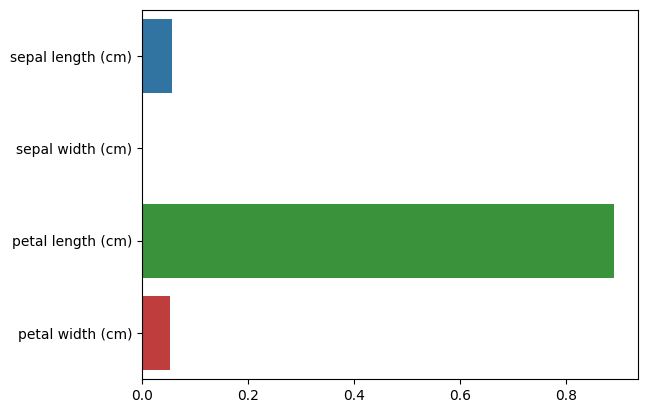

In [ ]:
print('Feature importances:\n{0}'.format(np.round(dt_HAR.feature_importances_, 3)))

# feature 별 importance 매핑
for name, value in zip(iris.feature_names, dt_HAR.feature_importances_):
    print('{0} : {1:.3f}'.format(name, value))

# feature importance를 column 별로 시각화하기
sns.barplot(x=dt_HAR.feature_importances_, y=iris.feature_names)

In [ ]:
!pip install graphviz

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


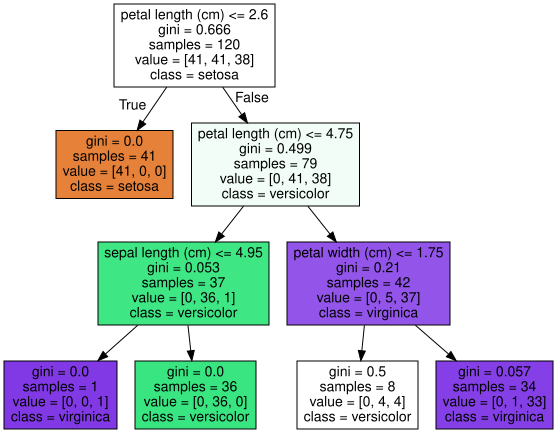

In [ ]:
from sklearn.tree import export_graphviz

import graphviz

export_graphviz(best_dt_HAR, out_file = "tree.dot", class_names = iris.target_names, feature_names = iris.feature_names, impurity = True, filled = True)

#위에서 생성된 tree.dot 파일을 Graphviz가 읽어서 시각화
with open("tree.dot") as f:
    dot_graph = f.read()

graphviz.Source(dot_graph)